$$
\textbf{Nome: Gabriel Souza Almeida. } \\
\textbf{Matrícula: 2026010096}
$$

$$
\textbf{Nome: Valderi Alves de Souza Neto. } \\
\textbf{Matrícula: 2026010167}
$$

# IMPORTANDO O DATASET

In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd

# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
# print(heart_disease.metadata) 
  
# variable information 
# print(heart_disease.variables) 

# Deixando tudo em um pandas
df = pd.concat([X, y], axis=1)

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


# 1. A) e B), binarizando e tratando os nulos.

In [4]:
# Renomeando a coluna 'num' para 'target'
df = df.rename(columns={'num': 'target'})

# Tratando a coluna 'ca'
df['ca'] = df['ca'].fillna(df['ca'].median())

# Tratando a coluna 'thal'
df['thal'] = df['thal'].fillna(df['thal'].median())

# binarizando o target
df['target'] = (y > 0).astype(int)

df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


# 1. C) Separando em treino e teste

In [5]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["target"])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify = y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 242 amostras
Teste:  61 amostras


# 1. D) Escalonamento

In [6]:
from sklearn.preprocessing import StandardScaler

cols_continuas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()

X_train[cols_continuas] = scaler.fit_transform(X_train[cols_continuas])

X_test[cols_continuas] = scaler.transform(X_test[cols_continuas])  #Nao é necessario o fit_transform pois a media e a variancia ja foram calculados

# 2. Treinando o modelo, foram necessarias 5 interações.

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)

model.fit(X_train, y_train)

print(f"Modelo treinado, interações necessarias: {model.n_iter_[0]}")

t0 = model.intercept_
tvalues = model.coef_[0]

print(f"θ0 = {t0}")
print(f"θ1, θ2, ..., θ13 = {tvalues}")

Modelo treinado, interações necessarias: 5
θ0 = [-3.28811152]
θ1, θ2, ..., θ13 = [-0.10925907  0.80147376  0.20239475  0.22261696  0.14592214 -0.39679142
  0.17120683 -0.52839494  0.79853069  0.40277171 -0.14000677  0.99572313
  0.28787809]


# 3. Avaliando o modelo

In [8]:
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve, accuracy_score, 
    precision_score, recall_score, f1_score
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Matriz de confusão: \n{confusion_matrix(y_test, y_pred)}")

Matriz de confusão: 
[[27  6]
 [ 2 26]]


- Verdadeiro negativo: 27
- Falso negativo: 2
- Falso positivo: 6
- Verdadeiro: 26

In [9]:
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

Acurácia: 0.8689
Precisão: 0.8125
Recall: 0.9286
F1-Score: 0.8667


AUC-ROC:  0.9545


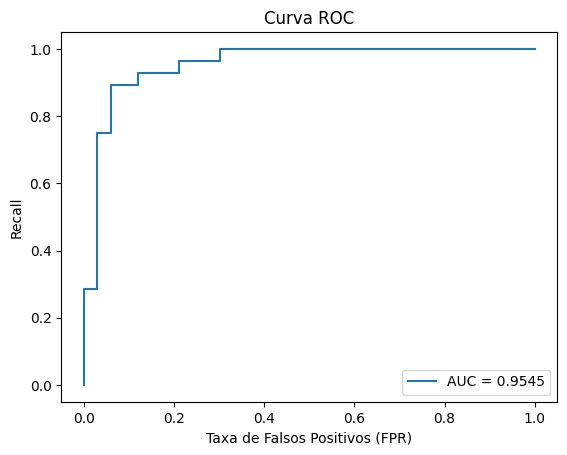

In [10]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")

# Plotar
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Recall')
plt.title('Curva ROC')
plt.legend()
plt.show()

## Matriz de Confusão
A matriz apresenta um equilíbrio excelente para o contexto médico, com 27 Verdadeiros Negativos e 26 Verdadeiros Positivos. O ponto mais forte é o baixo número de Falsos Negativos (2), o que significa que o modelo raramente deixa um paciente doente sair do hospital sem diagnóstico, mas, 2 casos de doentes saindo do hospital ainda é algo muito grave que precisa ser revisto no modelo. Os 6 Falsos Positivos indicam um viés conservador aceitável: é melhor investigar um paciente saudável do que ignorar um doente.

## Acurácia (0.8689)
Com 86,89% de acerto geral, o modelo demonstra uma performance sólida para uma ferramenta de triagem inicial. No contexto de doenças cardíacas, essa métrica confirma que a combinação das 13 variáveis clínicas (como age, chol e thal) é altamente preditiva quando o modelo é treinado corretamente.

## Precisão (0.8125)
A precisão de 81,25% indica que, de cada 10 pacientes que o modelo classificou "com doença", aproximadamente 8 realmente apresentavam a condição. Esse índice é crucial para evitar o estresse de falsos diagnósticos e a sobrecarga do sistema de saúde com exames de cateterismo desnecessários em pacientes saudáveis.

## Recall / Sensibilidade (0.9286)
Este é o indicador de maior valor para o seu projeto: o modelo identifica 92,86% de todos os doentes da amostra. Em saúde pública, o Recall alto é prioritário porque o custo de um "Falso Negativo" (não detectar a doença) pode ser a vida do paciente, e seu modelo cumpre bem o requisito mas para projetos futuros seria interessante tentar melhorar ainda mais esse indicador para evitar ao maximo falsos negativos.

## F1-Score (0.8667)
O F1-Score de 86,67% atesta o equilíbrio entre a Precisão e o Recall. Como o dataset de Cleveland possui classes relativamente balanceadas (164 saudáveis vs 139 doentes), esse valor alto confirma que o modelo é robusto e não está apenas "chutando" a classe mais frequente.

## Curva ROC e AUC (0.9545)
O valor de AUC-ROC (0.9545) é excepcional e indica que há uma probabilidade de 95% de o modelo classificar um paciente doente aleatório com um risco maior do que um saudável. Isso prova que a Regressão Logística, configurada com solver='liblinear', conseguiu separar quase perfeitamente as duas classes no espaço vetorial das características clínicas.